In [11]:
# -------------------------
# Import libraries
# -------------------------
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules

import joblib

In [13]:
# -------------------------
# Load raw datasets
# -------------------------
orders = pd.read_csv("datasets/orders.csv")
order_products_prior = pd.read_csv("datasets/order_products_prior.csv")
products = pd.read_csv("datasets/products.csv")
aisles = pd.read_csv("datasets/aisles.csv")
departments = pd.read_csv("datasets/departments.csv")

In [14]:
# -------------------------
# Merge datasets for EDA & preprocessing
# -------------------------
order_details = order_products_prior.merge(products, on="product_id") \
                                   .merge(aisles, on="aisle_id") \
                                   .merge(departments, on="department_id") \
                                   .merge(orders, on="order_id")

## EDA

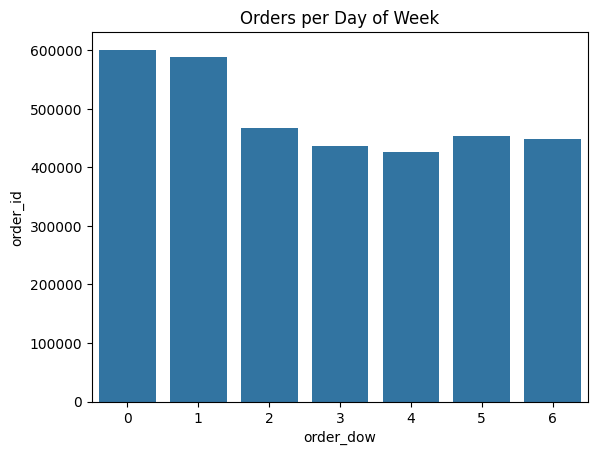

In [ ]:
# -------------------------
# -------------------------
# 1️⃣ Exploratory Data Analysis
# -------------------------
# Orders per day of week
orders_per_day = orders.groupby("order_dow")["order_id"].count().reset_index()
orders_per_day.to_csv("orders_per_day.csv", index=False)

plt.figure()
sns.barplot(x="order_dow", y="order_id", data=orders_per_day)
plt.title("Orders per Day of Week")
plt.show()


Most grocery orders occur on weekends.

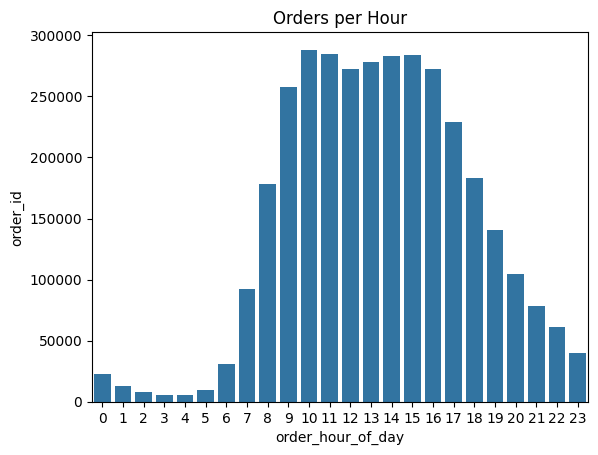

In [ ]:
# Orders per hour
orders_per_hour = orders.groupby("order_hour_of_day")["order_id"].count().reset_index()
orders_per_hour.to_csv("orders_per_hour.csv", index=False)

plt.figure()
sns.barplot(x="order_hour_of_day", y="order_id", data=orders_per_hour)
plt.title("Orders per Hour")
plt.show()

Peak grocery orders occur in afternoon hours.

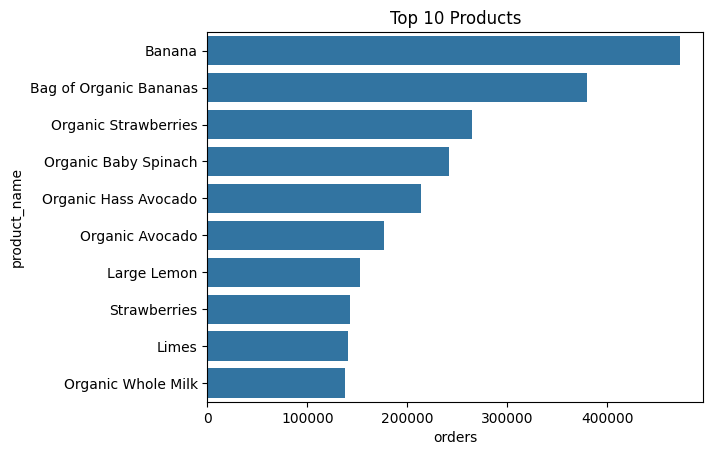

In [ ]:
# Top products
top_products = order_details["product_name"].value_counts().head(10).reset_index()
top_products.columns = ["product_name","orders"]
top_products.to_csv("top_products.csv", index=False)

plt.figure()
sns.barplot(x="orders", y="product_name", data=top_products)
plt.title("Top 10 Products")
plt.show()

Produce and Dairy dominate Instacart purchases.

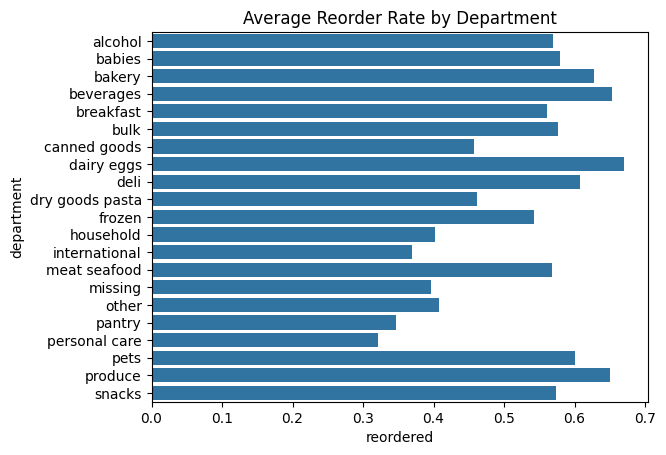

In [ ]:
# Department reorder rate
dept_reorder = order_details.groupby("department")["reordered"].mean().reset_index()
dept_reorder.to_csv("dept_reorder.csv", index=False)

plt.figure()
sns.barplot(x="reordered", y="department", data=dept_reorder)
plt.title("Average Reorder Rate by Department")
plt.show()

## OBJECTIVE 1
### Product Reorder Prediction

In [ ]:
# -------------------------
# -------------------------
# 2️⃣ Product Reorder Prediction
# -------------------------
# Sample orders to avoid memory issues
sample_orders = orders.sample(5000, random_state=42)
order_details_sample = order_products_prior[
    order_products_prior["order_id"].isin(sample_orders["order_id"])
].merge(sample_orders, on="order_id") \
 .merge(products, on="product_id") \
 .merge(aisles, on="aisle_id") \
 .merge(departments, on="department_id")

In [ ]:
# Save small datasets for Streamlit app
sample_orders.to_csv("orders_sample.csv", index=False)
order_details_sample.to_csv("order_details_sample.csv", index=False)
products.to_csv("products_lookup.csv", index=False)
aisles.to_csv("aisles_sample.csv", index=False)
departments.to_csv("departments_sample.csv", index=False)

In [15]:
sample_orders = orders.sample(20000, random_state=42)
order_details_sample = order_products_prior[
    order_products_prior["order_id"].isin(sample_orders["order_id"])
].merge(sample_orders, on="order_id") \
 .merge(products, on="product_id") \
 .merge(aisles, on="aisle_id") \
 .merge(departments, on="department_id")

In [16]:
# -------------------------
# Feature Engineering
# -------------------------
# 1️⃣ User-level features
user_features = order_details_sample.groupby("user_id").agg(
    total_orders=("order_number","max"),
    avg_days_between_orders=("days_since_prior_order","mean")
).fillna(0).reset_index()

In [17]:
# 2️⃣ Product-level features
product_features = order_details_sample.groupby("product_id").agg(
    product_popularity=("order_id","count"),
    product_reorder_rate=("reordered","mean")
).reset_index()

In [18]:
# 3️⃣ User-product interaction features
user_product_features = order_details_sample.groupby(["user_id","product_id"]).agg(
    purchase_count=("order_id","count")
).reset_index()

In [19]:
# Merge features
ml_data = user_product_features.merge(user_features, on="user_id") \
                               .merge(product_features, on="product_id")

In [20]:
# Check missing values
ml_data.isna().sum()

user_id                    0
product_id                 0
purchase_count             0
total_orders               0
avg_days_between_orders    0
product_popularity         0
product_reorder_rate       0
dtype: int64

In [21]:
# Add target column
target = order_details_sample.groupby(["user_id","product_id"])["reordered"].max().reset_index()
ml_data = ml_data.merge(target, on=["user_id","product_id"])
ml_data.rename(columns={"reordered":"target"}, inplace=True)

In [42]:
# Save ML features for Streamlit app
ml_data.to_csv("ml_features.csv", index=False)

In [22]:
# -------------------------
# Prepare training data
# -------------------------
feature_cols = ["total_orders","avg_days_between_orders",
                "product_popularity","product_reorder_rate","purchase_count"]

X = ml_data[feature_cols]
y = ml_data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## MODEL 1
### Logistic Regression
### Hyperparameter Tuning

In [24]:
# -------------------------
# Logistic Regression
# -------------------------
param_grid_log = {"C":[0.01, 0.1, 1, 10]}
log_model = LogisticRegression(max_iter=500)
grid_log = GridSearchCV(log_model, param_grid_log, cv=3, scoring="f1")
grid_log.fit(X_train_scaled, y_train)
best_log = grid_log.best_estimator_

## MODEL 2
### Random Forest

In [26]:
# -------------------------
# Random Forest
# -------------------------
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":[200,300,400],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2],
    "max_features":["sqrt","log2"]
}

rf = RandomForestClassifier(random_state=42, class_weight="balanced")

random_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=10,   # only 10 models tested
    cv=3,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

### Model Evaluation
### Logistic Regression

In [27]:
# -------------------------
# Evaluate models
# -------------------------
# Logistic Regression
log_pred = best_log.predict(X_test_scaled)
print("Logistic Regression Metrics")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_pred))

Logistic Regression Metrics
Accuracy: 0.7338627734103428
F1 Score: 0.7853522827751299
ROC AUC: 0.7137093995278502


In [28]:
# Random Forest
rf_pred = best_rf.predict(X_test)
print("\nRandom Forest Metrics")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))


Random Forest Metrics
Accuracy: 0.7596128135194395
F1 Score: 0.7964958348424483
ROC AUC: 0.750487895234309


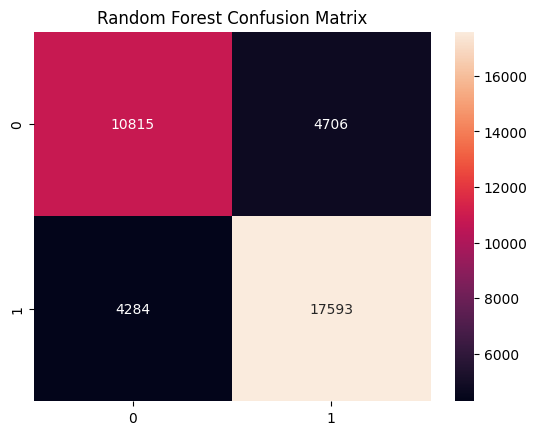

In [29]:
# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

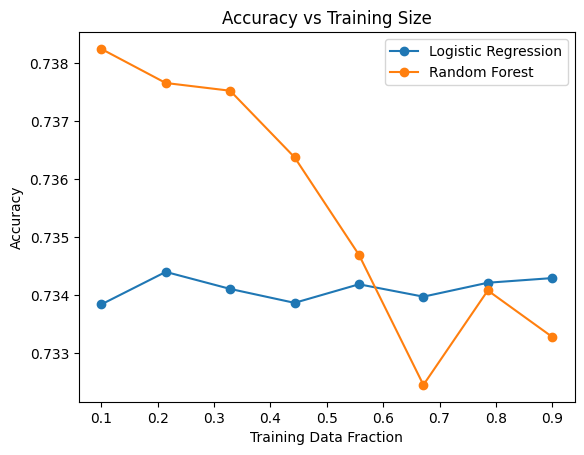

In [32]:
# ---------------------------------
# Accuracy vs Training Size
# ---------------------------------
train_sizes = np.linspace(0.1, 0.9, 8)

log_acc = []
rf_acc = []

for frac in train_sizes:
    
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train, train_size=frac, random_state=42, stratify=y_train
    )

    # Logistic Regression
    X_sub_scaled = scaler.transform(X_sub)
    log_model = LogisticRegression(max_iter=500)
    log_model.fit(X_sub_scaled, y_sub)
    log_pred = log_model.predict(X_test_scaled)
    log_acc.append(accuracy_score(y_test, log_pred))

    # Random Forest
    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_model.fit(X_sub, y_sub)
    rf_pred = rf_model.predict(X_test)
    rf_acc.append(accuracy_score(y_test, rf_pred))

plt.figure()

plt.plot(train_sizes, log_acc, marker='o', label="Logistic Regression")
plt.plot(train_sizes, rf_acc, marker='o', label="Random Forest")

plt.xlabel("Training Data Fraction")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Size")
plt.legend()
plt.show()

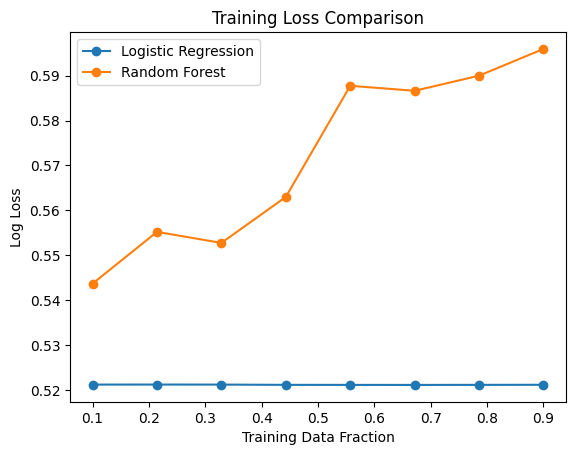

In [34]:
# ---------------------------------
# Log Loss vs Training Size
# ---------------------------------
from sklearn.metrics import log_loss

log_loss_list = []
rf_loss_list = []

for frac in train_sizes:
    
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train, train_size=frac, random_state=42, stratify=y_train
    )

    # Logistic Regression
    X_sub_scaled = scaler.transform(X_sub)
    log_model = LogisticRegression(max_iter=500)
    log_model.fit(X_sub_scaled, y_sub)

    log_probs = log_model.predict_proba(X_test_scaled)
    log_loss_list.append(log_loss(y_test, log_probs))

    # Random Forest
    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_model.fit(X_sub, y_sub)

    rf_probs = rf_model.predict_proba(X_test)
    rf_loss_list.append(log_loss(y_test, rf_probs))

plt.figure()

plt.plot(train_sizes, log_loss_list, marker='o', label="Logistic Regression")
plt.plot(train_sizes, rf_loss_list, marker='o', label="Random Forest")

plt.xlabel("Training Data Fraction")
plt.ylabel("Log Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [30]:
# -------------------------
# Save models & scaler
# -------------------------
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(best_log, "log_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## OBJECTIVE 2
### Customer Segmentation

In [41]:
# =========================
# 3️⃣ Customer Segmentation
# =========================
kmeans = KMeans(n_clusters=4, random_state=42)
user_features['cluster'] = kmeans.fit_predict(user_features[["total_orders","avg_days_between_orders"]])

# Save clusters for app
user_features.to_csv("user_clusters.csv", index=False)

# Cluster summary for dashboard cards
cluster_summary = user_features.groupby("cluster").agg(
    total_users=("user_id","count"),
    avg_orders=("total_orders","mean"),
    avg_days_between=("avg_days_between_orders","mean")
).reset_index()

cluster_summary.to_csv("cluster_summary.csv", index=False)

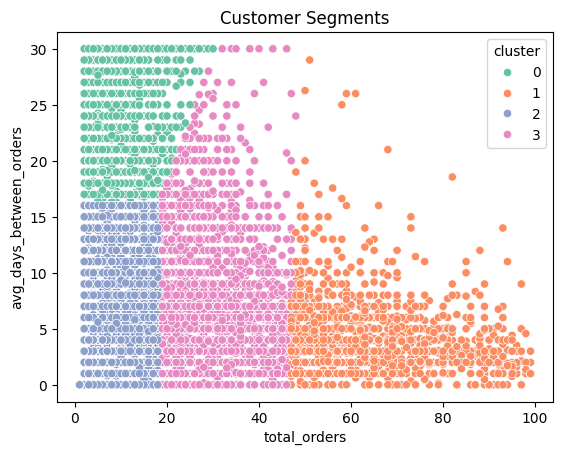

In [36]:
# Plotting clusters
if "cluster" not in user_features.columns:
    kmeans = KMeans(n_clusters=4, random_state=42)
    user_features["cluster"] = kmeans.fit_predict(
        user_features[["total_orders", "avg_days_between_orders"]]
    )

plt.figure()
sns.scatterplot(
    x="total_orders",
    y="avg_days_between_orders",
    hue="cluster",
    data=user_features,
    palette="Set2"
 )
plt.title("Customer Segments")
plt.show()

## OBJECTIVE 3
### Market Basket Analysis

In [40]:
# =========================
# 4️⃣ Market Basket Analysis
# =========================
basket = order_details_sample.groupby(['order_id','product_name'])['reordered'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x>0 else 0)

frequent_items = apriori(basket, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_items, metric='lift', min_threshold=1)

rules.to_csv("basket_analysis.csv", index=False)
print("Top 5 association rules:")
print(rules.head())

C:\Users\Thiwanka\AppData\Local\Temp\ipykernel_14044\2429984108.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x>0 else 0)
C:\Users\Thiwanka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Top 5 association rules:
                antecedents               consequents  antecedent support  \
0    (Organic Baby Spinach)  (Bag of Organic Bananas)            0.057475   
1  (Bag of Organic Bananas)    (Organic Baby Spinach)            0.097018   
2    (Organic Hass Avocado)  (Bag of Organic Bananas)            0.053220   
3  (Bag of Organic Bananas)    (Organic Hass Avocado)            0.097018   
4     (Organic Raspberries)  (Bag of Organic Bananas)            0.033545   

   consequent support   support  confidence      lift  representativity  \
0            0.097018  0.011380    0.198001  2.040878               1.0   
1            0.057475  0.011380    0.117299  2.040878               1.0   
2            0.097018  0.015209    0.285771  2.945557               1.0   
3            0.053220  0.015209    0.156764  2.945557               1.0   
4            0.097018  0.010083    0.300571  3.098099               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  